<a href="https://colab.research.google.com/github/fatma-hesham2/HEMAYA/blob/main/Fall_Detection_NoteBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00


In [3]:
import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Name: Tesla T4


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
PROJECT_DIR = "/content/drive/MyDrive/HEMAYA"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/HEMAYA


In [8]:
rf = Roboflow(api_key="0r8oTeltSdKVo6XJhMNR")
project = rf.workspace("fatma-hesham").project("fall-detection-ca3o8-rnbqo")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fall-Detection-2 in yolov8:: 100%|██████████| 8999/8999 [00:01<00:00, 8718.86it/s] 


In [14]:
path=dataset.location

In [15]:
print(os.listdir(path))

['test', 'README.roboflow.txt', 'train', 'data.yaml', 'valid', 'README.dataset.txt']


In [16]:
yaml_path = os.path.join(path, "data.yaml")
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data

{'names': ['Fall-Detected'],
 'nc': 1,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'fall-detection-ca3o8-rnbqo',
  'url': 'https://universe.roboflow.com/fatma-hesham/fall-detection-ca3o8-rnbqo/dataset/2',
  'version': 2,
  'workspace': 'fatma-hesham'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [17]:
from glob import glob

train_images = glob(os.path.join(path, "train", "images", "*"))
valid_images = glob(os.path.join(path, "valid", "images", "*"))
test_images = glob(os.path.join(path, "test", "images", "*"))

print(f"Train Images: {len(train_images)}")
print(f"Validation Images: {len(valid_images)}")
print(f"Test Images: {len(test_images)}")

print("-" * 30)

print(f"Total Images: {len(train_images)+len(valid_images)+len(test_images)}")

Train Images: 3148
Validation Images: 899
Test Images: 450
------------------------------
Total Images: 4497


In [18]:
train_labels = glob(os.path.join(path, "train", "labels", "*.txt"))
valid_labels = glob(os.path.join(path, "valid", "labels", "*.txt"))
test_labels = glob(os.path.join(path, "test", "labels", "*.txt"))

print("Train Labels:", len(train_labels))
print("Validation Labels:", len(valid_labels))
print("Test Labels:", len(test_labels))

print("-" * 30)

print("Total Labels:", len(train_labels) + len(valid_labels) + len(test_labels))

Train Labels: 3148
Validation Labels: 899
Test Labels: 450
------------------------------
Total Labels: 4497


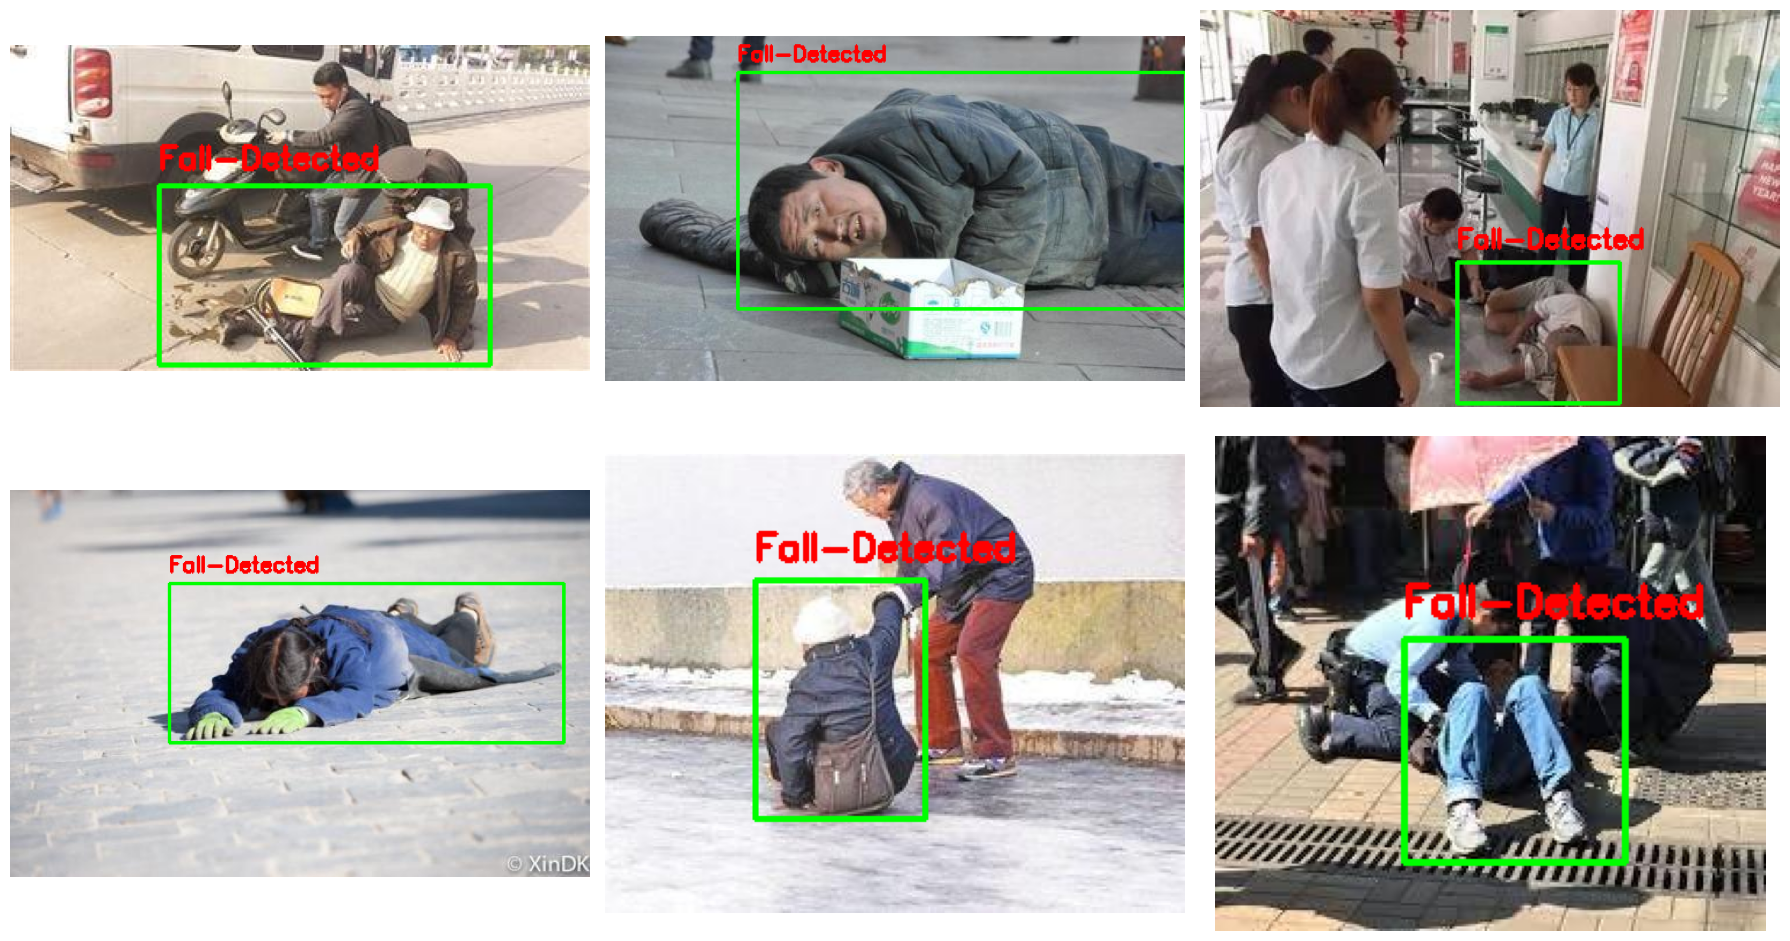

In [20]:
sample_images = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, sample_images):


    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = img_path.replace("images", "labels")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            for line in f.readlines():

                cls, x_center, y_center, bw, bh = map(float, line.split())


                x_center *= w
                y_center *= h
                bw *= w
                bh *= h

                x1 = int(x_center - bw / 2)
                y1 = int(y_center - bh / 2)
                x2 = int(x_center + bw / 2)
                y2 = int(y_center + bh / 2)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

                cv2.putText(
                    img,
                    data["names"][int(cls)],
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2
                )

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
model = YOLO("yolo26n.pt")

In [25]:
results = model.train(
    data= yaml_path,

    epochs=50,
    imgsz=640,
    batch=16,

    device=0,

    project=PROJECT_DIR,
    name="Fall_Detection_YOLO26N",

    optimizer="SGD",
    lr0=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    pretrained=True,

    workers=2,
    patience=20,

    save=True,
    plots=True,
    val=True,

    seed=42
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fall-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Fall_Detection_YOLO26N-2,

In [26]:
print(results.save_dir)

/content/drive/MyDrive/HEMAYA/Fall_Detection_YOLO26N-2


In [27]:
best_model = YOLO(os.path.join(results.save_dir, "weights", "best.pt"))

metrics = best_model.val()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1246.2±815.4 MB/s, size: 44.6 KB)
val: Scanning /content/Fall-Detection-2/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 235.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.5it/s 8.8s
                   all        899        899       0.88      0.852      0.909      0.639
Speed: 1.2ms preprocess, 4.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val



image 1/1 /content/Fall-Detection-2/test/images/people-5332-_jpg.rf.f07e28ae6c7fd472c6ce8cfc20662ab9.jpg: 640x576 1 Fall-Detected, 10.4ms
Speed: 3.1ms preprocess, 10.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 576)
Results saved to /content/runs/detect/predict


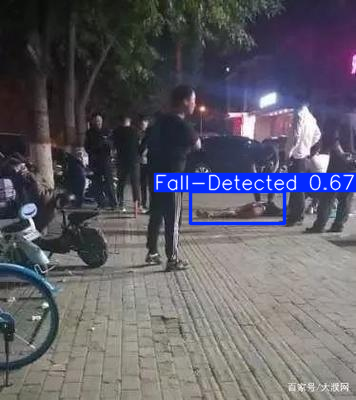

In [32]:
results = best_model.predict(
    source=test_images[0],
    conf=0.5,
    save=True
)

results[0].show()